<a href="https://colab.research.google.com/github/Ishikacasley14/AI_notes/blob/main/baseline_Telco_customer_churn_IBM_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
import os

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn-ibm-dataset' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn-ibm-dataset


In [3]:
print(os.listdir(path))

['Telco_customer_churn.xlsx']


In [4]:
df = pd.read_excel(os.path.join(path, "Telco_customer_churn.xlsx"))
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.shape

(7043, 33)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [7]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


In [8]:
df.isna().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [9]:
df = df.drop(['CustomerID'], axis=1)
df.head()

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [10]:
features = ['Tenure Months','Monthly Charges','Total Charges']
for col in df.columns:
    if col not in features:
        print(col, df[col].unique())
        print("-"*50)


Count [1]
--------------------------------------------------
Country ['United States']
--------------------------------------------------
State ['California']
--------------------------------------------------
City ['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']
--------------------------------------------------
Zip Code [90003 90005 90006 ... 96128 96134 96146]
--------------------------------------------------
Lat Long ['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']
--------------------------------------------------
Latitude [33.964131 34.059281 34.048013 ... 40.346634 41.813521 39.191797]
--------------------------------------------------
Longitude [-118.272783 -118.30742  -118.293953 ... -120.386422 -121.492666
 -120.212401]
--------------------------------------------------
Gender ['Male' 'Female']
------------------------------

In [11]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


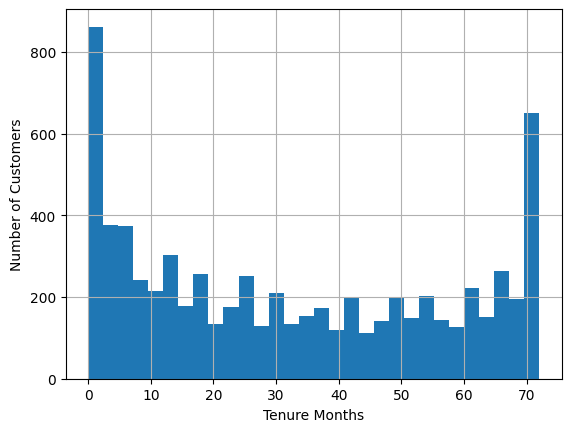

In [12]:
df['Tenure Months'].hist(bins=30)
plt.xlabel('Tenure Months')
plt.ylabel('Number of Customers')
plt.show()

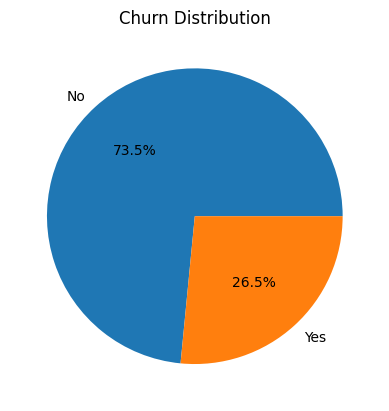

In [13]:
# Count values
counts = df['Churn Label'].value_counts()
# Labels (Yes / No)
labels = counts.index

# Plot pie chart
plt.pie(counts, labels=labels, autopct='%1.1f%%')

plt.title('Churn Distribution')
plt.show()

In [14]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.dropna(subset=['Total Charges'], inplace=True)

In [15]:
df['Total Charges'].dtype

dtype('float64')

In [16]:
gender_churn = pd.crosstab(df['Gender'], df['Churn Label'],normalize='index')*100
gender_churn

Churn Label,No,Yes
Gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


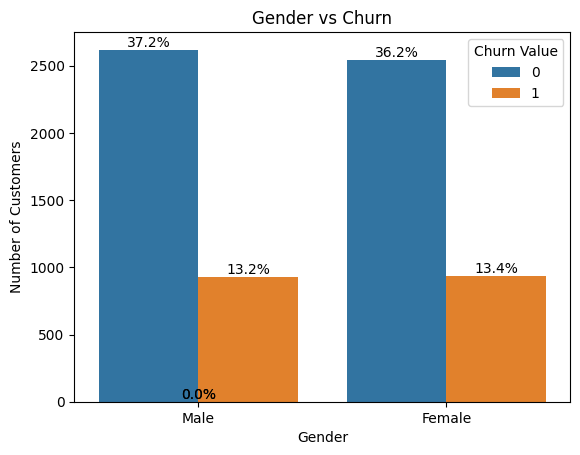

In [17]:
total = len(df)
ax= sns.countplot(data=df,x='Gender',hue='Churn Value')
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.title('Gender vs Churn')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

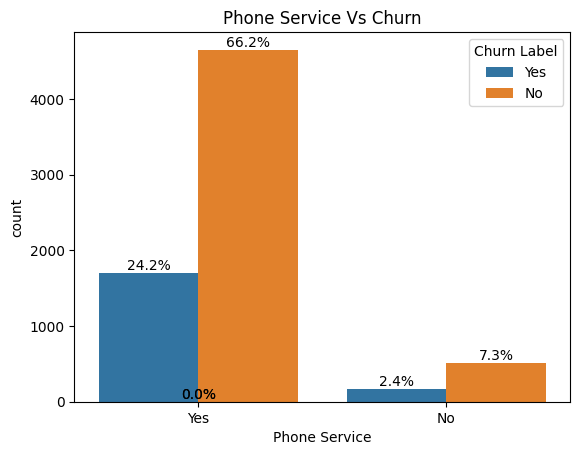

Most customers have phone service.


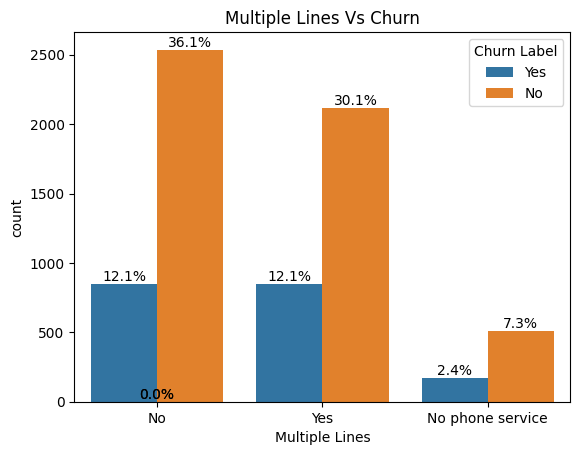

Customers without multiple lines have slightly lower churn.


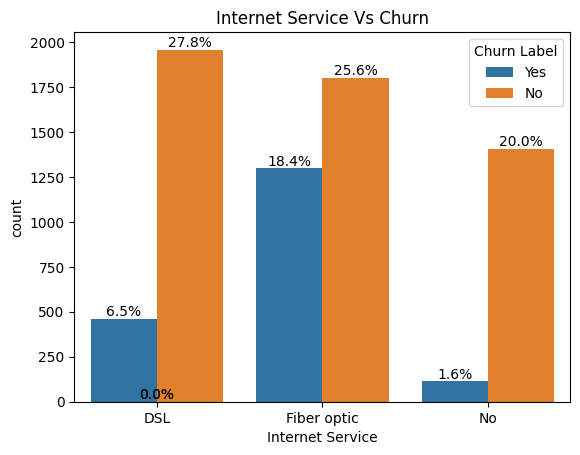

Fiber optic users tend to churn more; no internet service rarely churns.


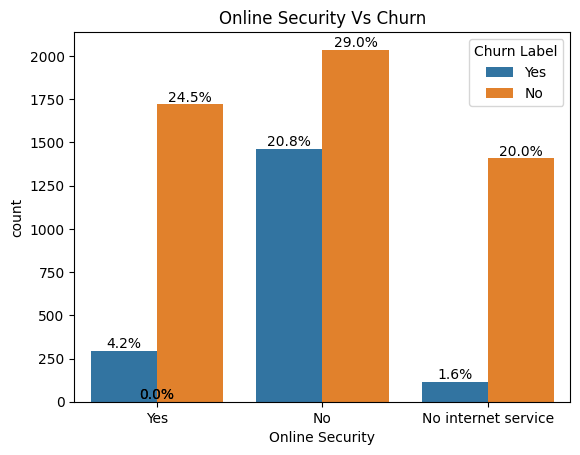

Customers without online security show higher churn.


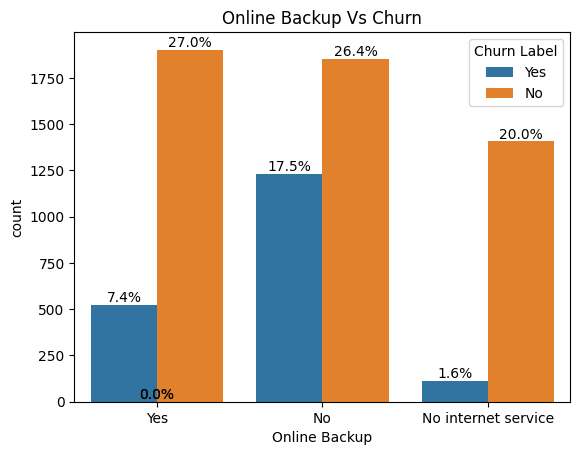

Customers without online backup churn more; backup helps retention.


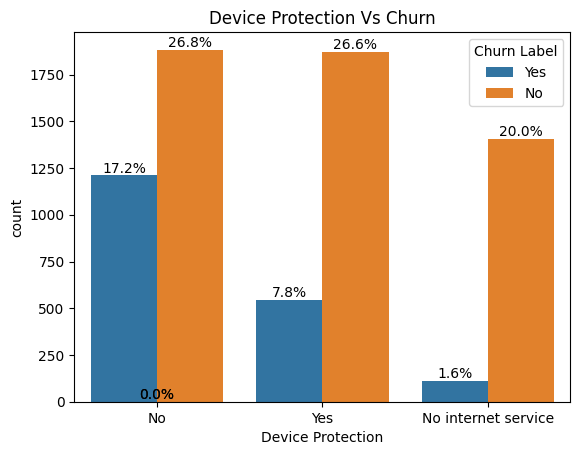

Lacking device protection correlates with higher churn.


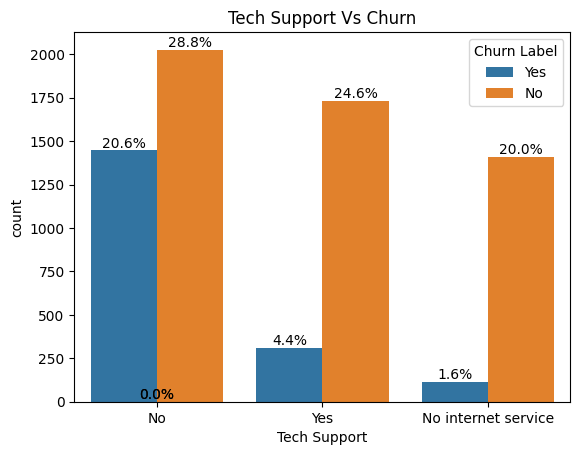

No tech support is strongly linked to higher churn.


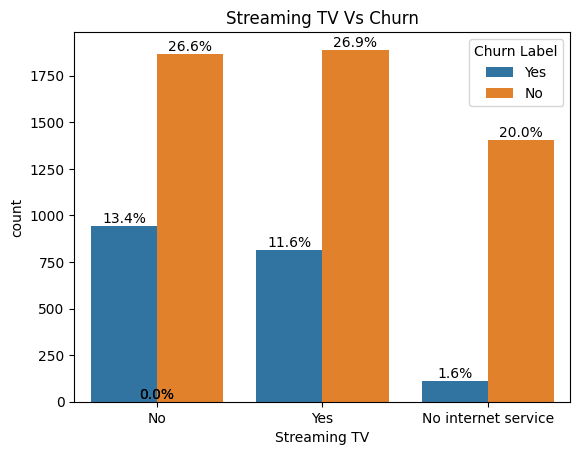

Streaming TV may slightly decrease churn.


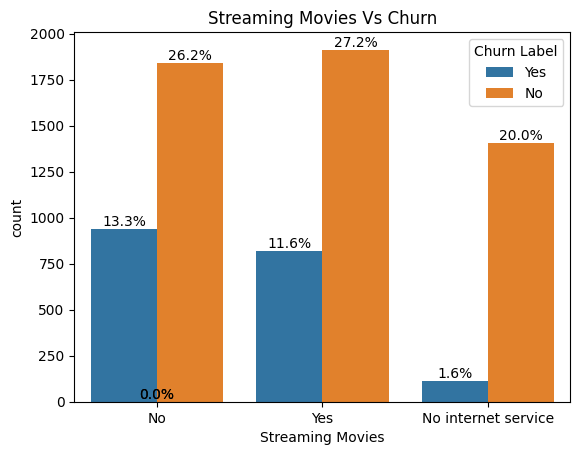

Similar to streaming TV, streaming movies have a small effect on churn.


In [18]:
service_cols = ['Phone Service', 'Multiple Lines', 'Internet Service',
                'Online Security', 'Online Backup', 'Device Protection',
                'Tech Support', 'Streaming TV', 'Streaming Movies']

# Dictionary of comments for each column
comments = {
    'Phone Service': "Most customers have phone service.",
    'Multiple Lines': "Customers without multiple lines have slightly lower churn.",
    'Internet Service': "Fiber optic users tend to churn more; no internet service rarely churns.",
    'Online Security': "Customers without online security show higher churn.",
    'Online Backup': "Customers without online backup churn more; backup helps retention.",
    'Device Protection': "Lacking device protection correlates with higher churn.",
    'Tech Support': "No tech support is strongly linked to higher churn.",
    'Streaming TV': "Streaming TV may slightly decrease churn.",
    'Streaming Movies': "Similar to streaming TV, streaming movies have a small effect on churn."
}

for col in service_cols:
  ax = sns.countplot(data=df, x=col, hue='Churn Label')
  total = len(df)
  for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
  plt.title(f"{col} Vs Churn")
  plt.show()
  print(comments[col])

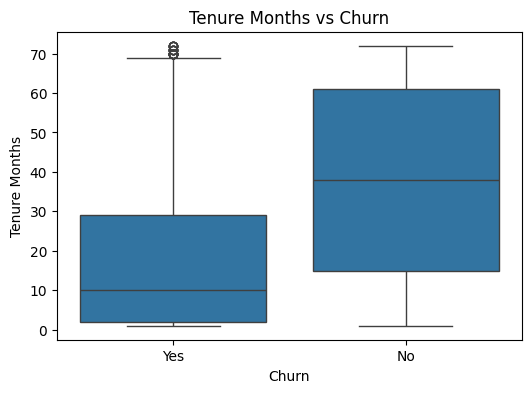

Customers with shorter tenure are more likely to churn. Longer-tenured customers tend to stay, showing that loyalty increases over time.



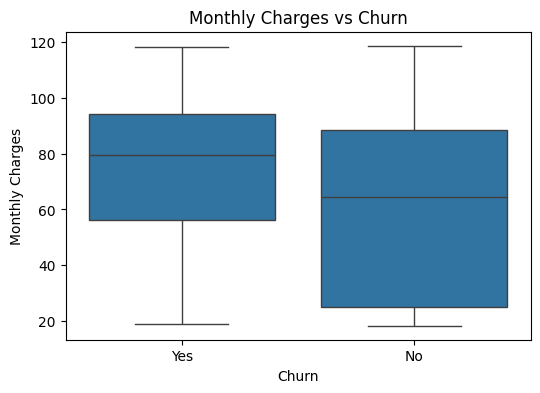

Customers with higher monthly charges show a slightly higher churn rate. Low-to-mid charges are associated with more retained customers.



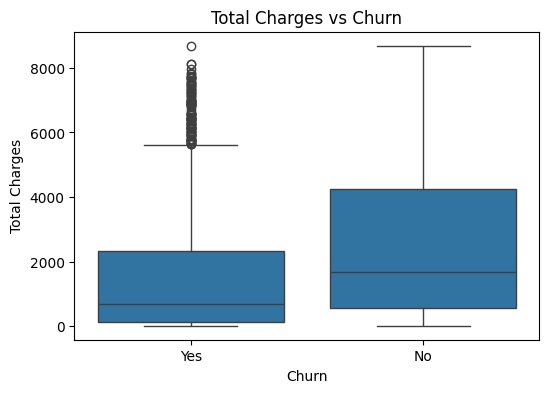

Customers with low total charges tend to churn more, usually because they are newer customers. High total charges often indicate long-term customers who are less likely to churn.



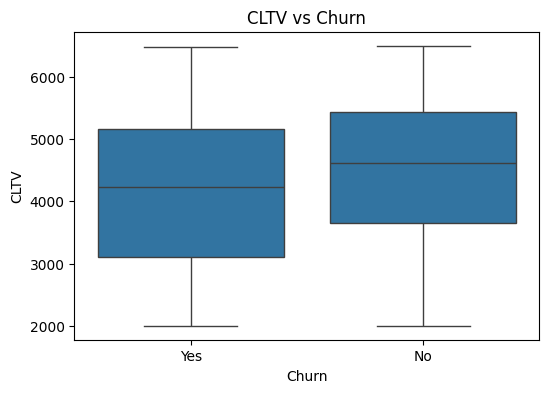

Customers with low CLTV are more likely to churn. Higher CLTV correlates with retention, suggesting these customers are more valuable and loyal.



In [19]:
#Ensure numeric columns are truly numeric
numeric_cols = ['Tenure Months','Monthly Charges','Total Charges','CLTV']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Optional: drop rows with missing values for these columns
my_data_clean = df.dropna(subset=numeric_cols)

numeric_comments = { 'Tenure Months': "Customers with shorter tenure are more likely to churn. Longer-tenured customers tend to stay, showing that loyalty increases over time.",
                    'Monthly Charges': "Customers with higher monthly charges show a slightly higher churn rate. Low-to-mid charges are associated with more retained customers.",
                    'Total Charges': "Customers with low total charges tend to churn more, usually because they are newer customers. High total charges often indicate long-term customers who are less likely to churn.",
                    'CLTV': "Customers with low CLTV are more likely to churn. Higher CLTV correlates with retention, suggesting these customers are more valuable and loyal." }

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn Label', y=col, data=my_data_clean)
    plt.title(f"{col} vs Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

    print(f"{numeric_comments[col]}\n")

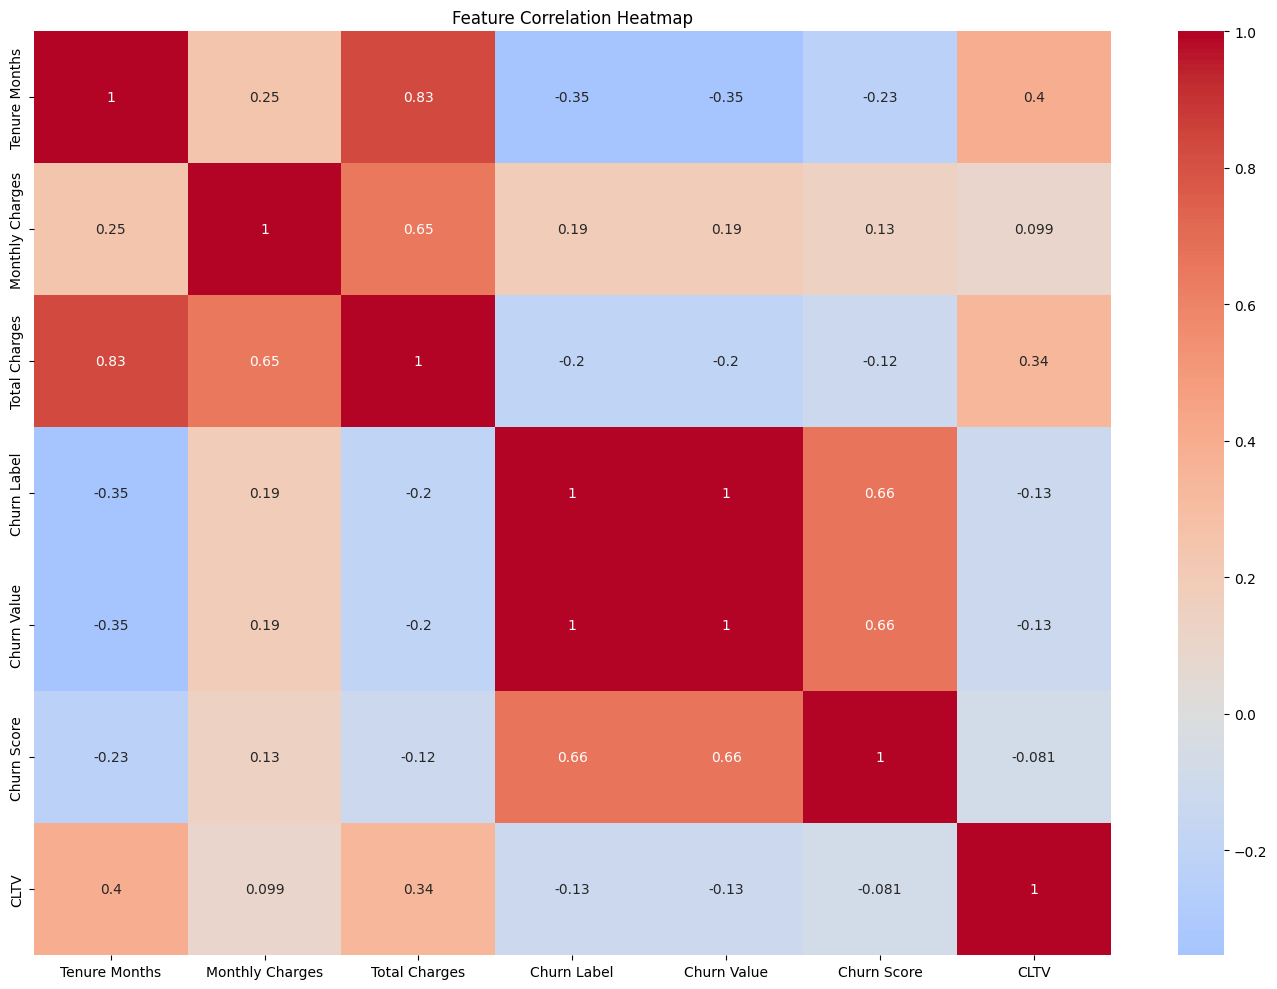

In [20]:
# Correlation Heatmap (excluding geographic and leakage columns)
exclude_cols = ['Count','Country','State','City','Zip Code','LatLong','Latitude','Longitude','ChurnValue','ChurnScore']
heatmap_data = df.drop(columns=[c for c in exclude_cols if c in df.columns])

# Convert ChurnLabel to numeric for correlation
heatmap_data['Churn Label'] = heatmap_data['Churn Label'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

TenureMonths and TotalCharges are highly correlated, which makes sense because longer customers accumulate more charges. MonthlyCharges shows a moderate positive correlation with churn, while TenureMonths shows a negative one, confirming that newer customers with higher bills are at the greatest risk.

In [21]:
drop_cols = [
    'Count', 'Country', 'State', 'City',
    'Zip Code', 'Lat Long', 'Latitude', 'Longitude'
]

df = df.drop(columns=drop_cols)

df = df.drop(columns=['Churn Value', 'Churn Score'])

In [24]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV,Churn Reason
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239,Competitor made better offer
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701,Moved
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,5372,Moved
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003,Moved
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,5340,Competitor had better devices


In [27]:
cols_to_numeric = ['Total Charges', 'Monthly Charges']
df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

In [29]:
df.drop(columns = 'Churn Reason', inplace = True)

In [30]:
df = df.dropna()

In [36]:
df.select_dtypes(include='object').columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Churn Label'],
      dtype='object')

In [37]:
df = df.copy()
binary_col = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing',
       'Churn Label']
for col in binary_col:
    df[col] = df[col].replace({
        'Yes':1, 'No':0,
        'Male':1, 'Female':0,
        'No internet service':0,
        'No phone service':0
    })

/tmp/ipykernel_34531/2981971605.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [38]:
df[binary_col].head()

,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Churn Label
0,1,0,0,0,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,1
1,0,0,0,1,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,1
2,0,0,0,1,1,1,Fiber optic,0,0,1,0,1,1,Month-to-month,1,Electronic check,1
3,0,0,1,1,1,1,Fiber optic,0,0,1,1,1,1,Month-to-month,1,Electronic check,1
4,1,0,0,1,1,1,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Bank transfer (automatic),1


In [39]:
multi_cat_cols = ['Internet Service','Contract','Payment Method']
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Gender                                  7032 non-null   int64  
 1   Senior Citizen                          7032 non-null   int64  
 2   Partner                                 7032 non-null   int64  
 3   Dependents                              7032 non-null   int64  
 4   Tenure Months                           7032 non-null   int64  
 5   Phone Service                           7032 non-null   int64  
 6   Multiple Lines                          7032 non-null   int64  
 7   Online Security                         7032 non-null   int64  
 8   Online Backup                           7032 non-null   int64  
 9   Device Protection                       7032 non-null   int64  
 10  Tech Support                            7032 non-null   int64  
 

In [41]:
bool_col = df.select_dtypes(include='bool').columns
df[bool_col] = df[bool_col].astype(int)

In [43]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,...,Total Charges,Churn Label,CLTV,Internet Service_DSL,Internet Service_Fiber optic,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,1,0,0,0,2,1,0,1,1,0,...,108.15,1,3239,1,0,0,0,0,0,1
1,0,0,0,1,2,1,0,0,0,0,...,151.65,1,2701,0,1,0,0,0,1,0
2,0,0,0,1,8,1,1,0,0,1,...,820.50,1,5372,0,1,0,0,0,1,0
3,0,0,1,1,28,1,1,0,0,1,...,3046.05,1,5003,0,1,0,0,0,1,0
4,1,0,0,1,49,1,1,0,1,1,...,5036.30,1,5340,0,1,0,0,0,0,0


In [45]:
standard_scaler = StandardScaler()
scale_cols = ['Tenure Months','Monthly Charges','Total Charges','CLTV']
df[scale_cols] = standard_scaler.fit_transform(df[scale_cols])

In [46]:
df[scale_cols].head()

,Tenure Months,Monthly Charges,Total Charges,CLTV
0,-1.239504,-0.363923,-0.959649,-0.983181
1,-1.239504,0.196178,-0.940457,-1.438215
2,-0.995040,1.158489,-0.645369,0.820883
3,-0.180161,1.329677,0.336516,0.508788
4,0.675462,1.293113,1.214589,0.793818


Model Evaluation

In [47]:
X = df.drop('Churn Label', axis=1)
y = df['Churn Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Accuracy: 0.8152096659559346
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1012
           1       0.71      0.59      0.64       395

    accuracy                           0.82      1407
   macro avg       0.78      0.75      0.76      1407
weighted avg       0.81      0.82      0.81      1407



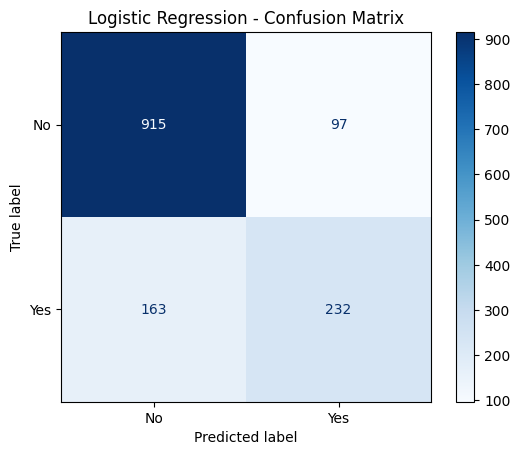

In [50]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No', 'Yes'], cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

Accuracy: 0.7910447761194029
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1012
           1       0.67      0.50      0.57       395

    accuracy                           0.79      1407
   macro avg       0.75      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407



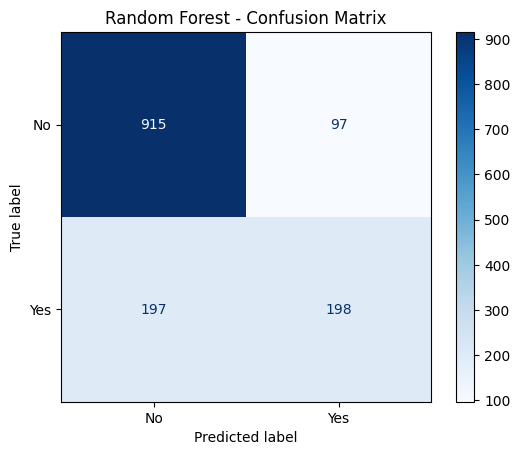

In [51]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Predict

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

from sklearn.metrics import ConfusionMatrixDisplay

# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['No', 'Yes'], cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy: 0.8109452736318408
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1012
           1       0.71      0.56      0.62       395

    accuracy                           0.81      1407
   macro avg       0.77      0.73      0.75      1407
weighted avg       0.80      0.81      0.80      1407



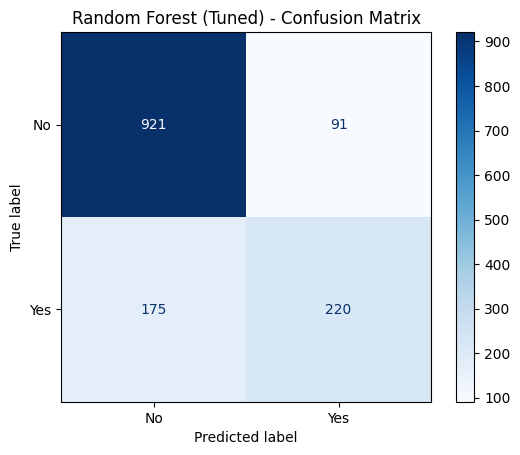

In [53]:
 #Tune Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid,
                       cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)

# Use best model
rf = rf_grid.best_estimator_
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['No', 'Yes'], cmap='Blues')
plt.title('Random Forest (Tuned) - Confusion Matrix')
plt.show()

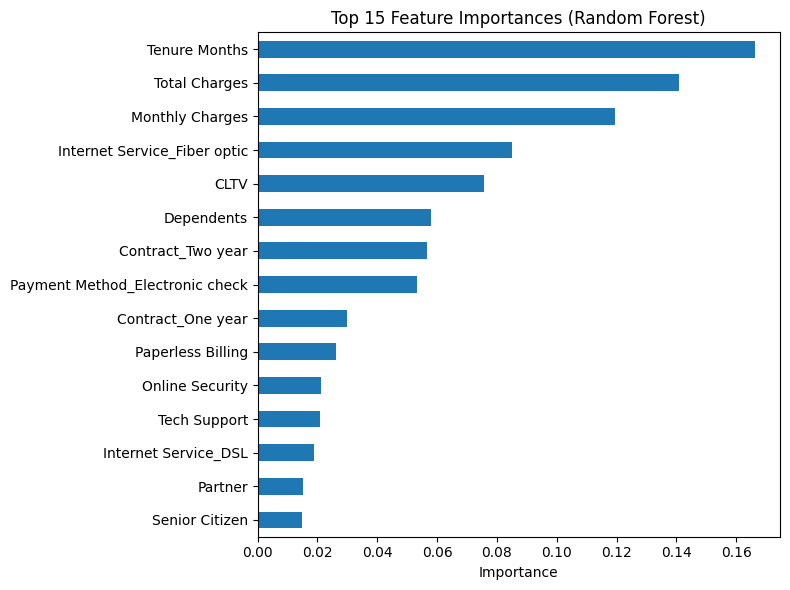

In [54]:
# Top 15 most important features from Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

Accuracy: 0.8009950248756219
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1012
           1       0.67      0.57      0.62       395

    accuracy                           0.80      1407
   macro avg       0.76      0.73      0.74      1407
weighted avg       0.79      0.80      0.80      1407



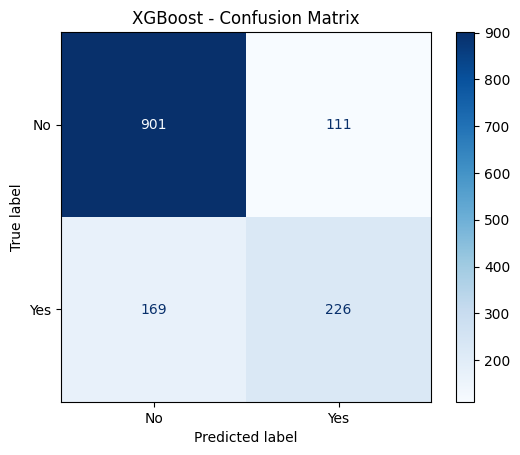

In [55]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, display_labels=['No', 'Yes'], cmap='Blues')
plt.title('XGBoost - Confusion Matrix')
plt.show()

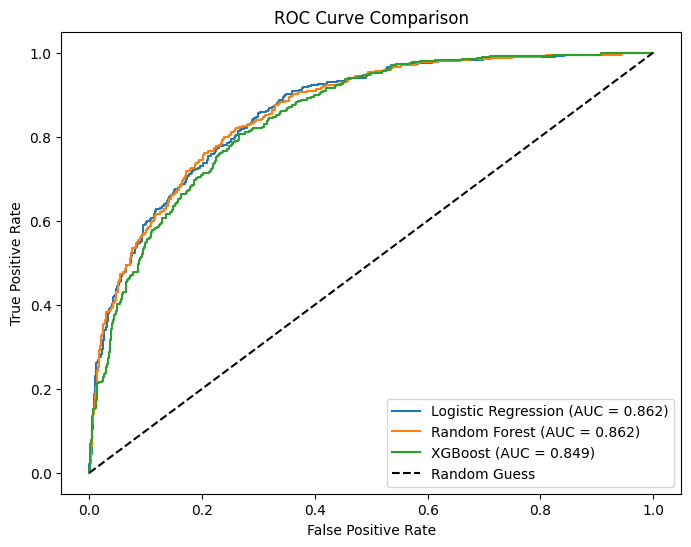

In [56]:
# Get predicted probabilities
y_prob_lr = model.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Plot ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


In [57]:
# Model Comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest (Tuned)', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    'Churn Recall': [
        classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['recall']
    ]
}).sort_values('AUC', ascending=False)

display(results)

,Model,Accuracy,AUC,Churn Recall
0,Logistic Regression,0.815210,0.862100,0.587342
1,Random Forest (Tuned),0.810945,0.861563,0.556962
2,XGBoost,0.800995,0.849007,0.572152
